<a href="https://colab.research.google.com/github/sevla7/Projeto-Trainee-Dados/blob/main/projeto_trainee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Ciência de Dados — Previsão de Preços de Imóveis

Este notebook desenvolve um projeto completo de **aprendizado supervisionado para regressão** usando os arquivos `train.csv`, `test.csv`, `sample_submission.csv` e `data_description.txt`.

O objetivo é prever `SalePrice`, o preço de venda de cada imóvel. Ao longo do projeto são explicados os conceitos, o código e as funções utilizadas.

## Etapas

1. entendimento do problema;
2. inspeção e qualidade dos dados;
3. análise exploratória;
4. valores ausentes e outliers;
5. engenharia de variáveis;
6. pré-processamento;
7. comparação de modelos;
8. validação e métricas;
9. interpretação;
10. geração da submissão.

## 1. Conceitos fundamentais

### Aprendizado supervisionado
O modelo recebe exemplos com entradas `X` e uma resposta conhecida `y`. Ele aprende uma relação para prever novos casos.

### Regressão
É usada quando o alvo é numérico contínuo. Aqui, `SalePrice` é o valor da casa.

### Features e alvo
- **Features (`X`)**: área, bairro, qualidade, garagem, idade etc.
- **Alvo (`y`)**: `SalePrice`.

### Generalização
Um bom modelo não deve apenas memorizar o treino. Ele precisa funcionar bem em imóveis que nunca viu.

## 2. Importação das bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    silhouette_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


### O que cada biblioteca faz
- `pandas`: tabelas e DataFrames;
- `numpy`: cálculos numéricos;
- `matplotlib` e `seaborn`: gráficos;
- `sklearn`: pré-processamento, modelos e métricas;
- `Pipeline`: une transformação e modelo de maneira segura.

## 3. Carregamento dos dados

In [40]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')
sample_submission = pd.read_csv('/content/sample_submission.csv')

print('Treino:', train_df.shape)
print('Teste:', test_df.shape)
print('Submissão:', sample_submission.shape)

Treino: (1460, 81)
Teste: (1459, 80)
Submissão: (1459, 2)


- `train.csv` possui as variáveis e `SalePrice`;
- `test.csv` não possui o alvo;
- `sample_submission.csv` informa o formato final;
- `pd.read_csv()` transforma um CSV em DataFrame.

In [ ]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 4. Inspeção inicial

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
quality = pd.DataFrame({
    'tipo': train_df.dtypes.astype(str),
    'nulos': train_df.isna().sum(),
    'nulos_pct': (train_df.isna().mean()*100).round(2),
    'unicos': train_df.nunique()
}).sort_values('nulos_pct', ascending=False)
quality.head(20)

,tipo,nulos,nulos_pct,unicos
PoolQC,object,1453,99.52,3
MiscFeature,object,1406,96.30,4
Alley,object,1369,93.77,2
Fence,object,1179,80.75,4
MasVnrType,object,872,59.73,3
FireplaceQu,object,690,47.26,5
LotFrontage,float64,259,17.74,110
GarageQual,object,81,5.55,5
GarageFinish,object,81,5.55,3
GarageType,object,81,5.55,6


- `isna()` identifica ausentes;
- `sum()` conta;
- `mean()` calcula proporção;
- `nunique()` conta valores diferentes.
- `info()` exibe os tipos de dados.
- `describe()` mostra média, desvio padrão, mínimo, quartis e máximo.
- O `.T` transpõe a tabela.

Neste dataset, alguns nulos significam ausência real, como não possuir piscina ou garagem.

In [ ]:
print('Duplicatas completas:', train_df.duplicated().sum())
print('IDs duplicados:', train_df['Id'].duplicated().sum())

Duplicatas completas: 0
IDs duplicados: 0


`Id` é apenas identificador. Ele será removido das features porque não descreve a casa.

## 5. Estatísticas descritivas

In [ ]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 6. Análise da variável-alvo

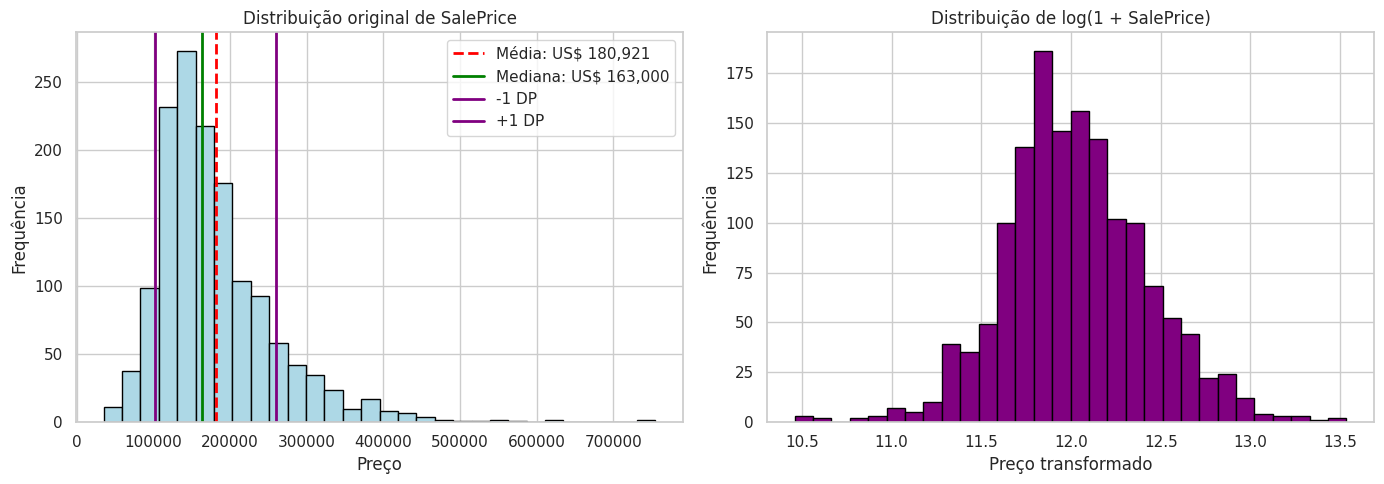

In [ ]:
media = train_df["SalePrice"].mean()
mediana = train_df["SalePrice"].median()
desvio = train_df["SalePrice"].std()

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(train_df['SalePrice'], bins=30, edgecolor='black', color='lightblue')
axes[0].axvline(media, color='red', linestyle="--",  linewidth=2, label=f"Média: US$ {media:,.0f}")
axes[0].axvline(mediana, color='green', linestyle="-", linewidth=2, label=f"Mediana: US$ {mediana:,.0f}")
axes[0].axvline(media-desvio, color='purple', linestyle='-', linewidth=2, label='-1 DP')
axes[0].axvline(media+desvio, color='purple', linestyle='-', linewidth=2, label='+1 DP')
axes[0].set_title('Distribuição original de SalePrice')
axes[0].set_xlabel('Preço')
axes[0].set_ylabel('Frequência')
axes[0].legend()


axes[1].hist(np.log1p(train_df['SalePrice']), bins=30, edgecolor='black', color='purple')
axes[1].set_title('Distribuição de log(1 + SalePrice)')
axes[1].set_xlabel('Preço transformado')
axes[1].set_ylabel('Frequência')
plt.tight_layout(); plt.show()

### Transformação logarítmica
`np.log1p(x)` calcula `log(1+x)`. Ela reduz assimetria e a influência relativa de imóveis muito caros. Depois usamos `np.expm1()` para voltar à escala original.

O histograma da esquerda mostra a distribuição dos preços de venda. A média aparece à direita da mediana, indicando que alguns imóveis de alto valor elevam a média. Isso confirma que a distribuição é assimétrica à direita e justifica a aplicação da transformação logarítmica em SalePrice.

O preço médio dos imóveis foi de aproximadamente US\$ 181 mil, enquanto o desvio padrão foi de cerca de US\$ 79 mil. Esse valor representa aproximadamente 44% da média, indicando elevada dispersão e a presença de imóveis em diferentes faixas de preço. Além disso, a média superior à mediana confirma que imóveis de alto valor influenciam a distribuição, tornando-a assimétrica à direita.

## 7. Correlação

In [ ]:
corr_target = train_df.corr(numeric_only=True)['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)
corr_target.head(15)

,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


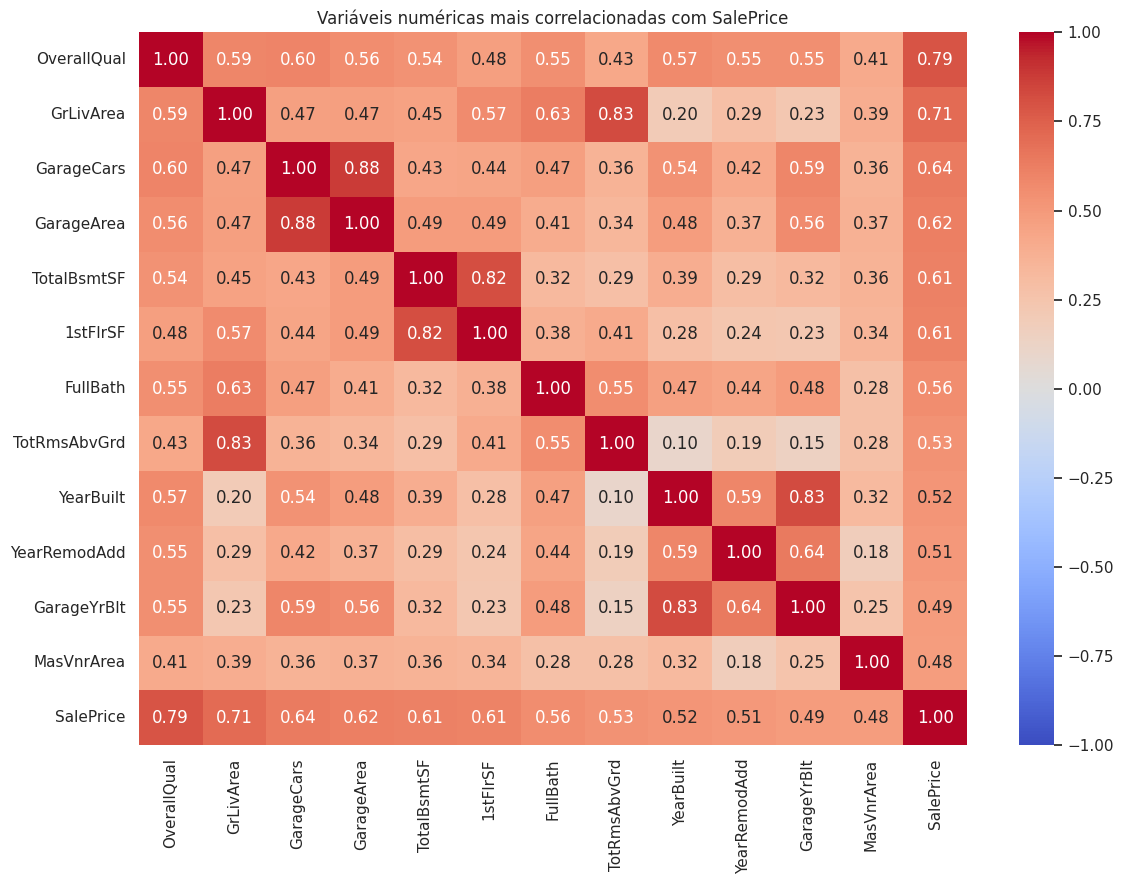

In [ ]:
top = corr_target.head(12).index.tolist() + ['SalePrice']
plt.figure(figsize=(12,9))
sns.heatmap(train_df[top].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Variáveis numéricas mais correlacionadas com SalePrice')
plt.tight_layout(); plt.show()

Correlação mede associação linear entre -1 e 1. Não prova causalidade e pode não capturar relações não lineares.

## 8. Relações e possíveis outliers

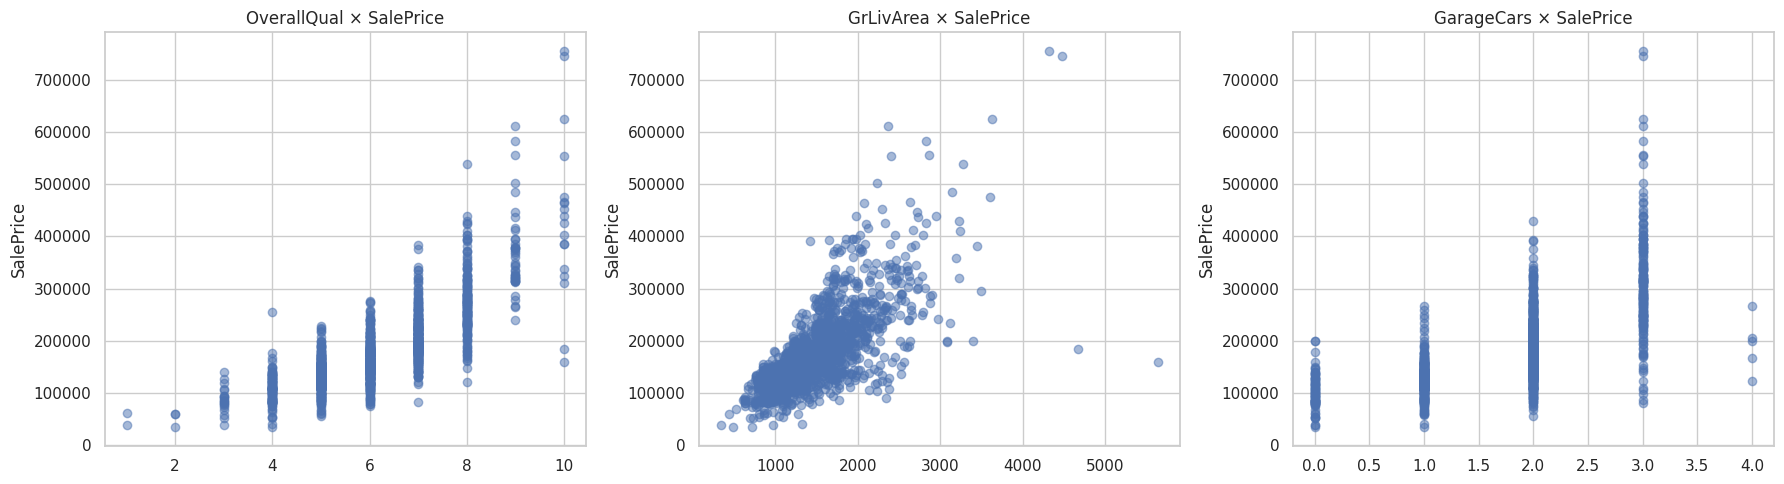

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(train_df['OverallQual'], train_df['SalePrice'], alpha=.5)
axes[0].set_title('OverallQual × SalePrice')
axes[1].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=.5)
axes[1].set_title('GrLivArea × SalePrice')
axes[2].scatter(train_df['GarageCars'], train_df['SalePrice'], alpha=.5)
axes[2].set_title('GarageCars × SalePrice')
for ax in axes: ax.set_ylabel('SalePrice')
plt.tight_layout(); plt.show()

Outliers são valores muito distantes dos demais. Eles não devem ser removidos automaticamente: podem ser imóveis reais. Neste projeto, mantemos os dados e usamos transformação logarítmica e modelos robustos.

`OverallQual`: A qualidade geral da construção apresenta forte relação positiva com o preço dos imóveis, indicando que casas de maior qualidade tendem a possuir maior valor de mercado. Apesar disso, existem alguns outliers, sugerindo que outros fatores também influenciam o preço.

`GrLiveArea`: Existe forte relação positiva entre área construída e preço dos imóveis. Entretanto, algumas casas muito grandes apresentam preços inferiores ao esperado, caracterizando outliers que podem influenciar a modelagem.

`GarageCars`: A capacidade da garagem apresenta relação positiva com o preço de venda. Em geral, imóveis com maior capacidade de garagem tendem a possuir maior valor, embora existam diferenças explicadas por outras características do imóvel.

Observa-se que a maior parte dos imóveis possui área habitável entre aproximadamente 500 e 3000 pés², indicando que essa é a faixa predominante do conjunto de dados. Casas com áreas superiores são menos frequentes e aparecem como pontos mais dispersos no gráfico. Além disso, alguns imóveis muito grandes apresentam preços inferiores ao esperado, caracterizando outliers que podem afetar a modelagem e justificam a utilização de técnicas robustas e transformações, como a aplicação do logaritmo em SalePrice."

## 9. Engenharia de variáveis

In [ ]:
def create_features(df):
    data = df.copy()
    data['TotalSF'] = data['TotalBsmtSF'].fillna(0) + data['1stFlrSF'].fillna(0) + data['2ndFlrSF'].fillna(0)
    data['TotalBathrooms'] = (data['FullBath'].fillna(0) + .5*data['HalfBath'].fillna(0)
                              + data['BsmtFullBath'].fillna(0) + .5*data['BsmtHalfBath'].fillna(0))
    data['TotalPorchSF'] = (data['OpenPorchSF'].fillna(0) + data['EnclosedPorch'].fillna(0)
                            + data['3SsnPorch'].fillna(0) + data['ScreenPorch'].fillna(0)
                            + data['WoodDeckSF'].fillna(0))
    data['HouseAge'] = data['YrSold'] - data['YearBuilt']
    data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']
    data['HasGarage'] = (data['GarageArea'].fillna(0) > 0).astype(int)
    data['HasBasement'] = (data['TotalBsmtSF'].fillna(0) > 0).astype(int)
    data['HasFireplace'] = (data['Fireplaces'].fillna(0) > 0).astype(int)
    data['HasPool'] = (data['PoolArea'].fillna(0) > 0).astype(int)
    return data

train_eng = create_features(train_df)
test_eng = create_features(test_df)
train_eng[[
    'TotalSF','TotalBathrooms','TotalPorchSF','HouseAge','RemodAge']].head()

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodAge
0,2566,3.5,61,5,5
1,2524,2.5,298,31,31
2,2706,3.5,42,7,6
3,2473,2.0,307,91,36
4,3343,3.5,276,8,8


Engenharia de variáveis combina informações existentes em medidas mais úteis. A função usa `copy()` para preservar o original, `fillna(0)` nas somas e `astype(int)` para converter booleanos em 0/1.

| Variável criada    | Objetivo                                                      |
| ------------------ | ------------------------------------------------------------- |
| **TotalSF**        | Área total construída do imóvel                               |
| **TotalBathrooms** | Quantidade total de banheiros (considerando lavabos como 0,5) |
| **TotalPorchSF**   | Área total de varandas e áreas externas                       |
| **HouseAge**       | Idade do imóvel na data da venda                              |
| **RemodAge**       | Tempo desde a última reforma                                  |
| **HasGarage**      | Indica presença de garagem                                    |
| **HasBasement**    | Indica presença de porão                                      |
| **HasFireplace**   | Indica presença de lareira                                    |
| **HasPool**        | Indica presença de piscina                                    |


## 10. Separação entre features e alvo

In [ ]:
X = train_eng.drop(columns=['SalePrice','Id'])
y = np.log1p(train_eng['SalePrice'])
X_test = test_eng.drop(columns=['Id'])
print(X.shape, y.shape, X_test.shape)

(1460, 88) (1460,) (1459, 88)


Remover `SalePrice` de `X` evita vazamento de dados. O alvo é transformado com logaritmo.

## 11. Treino e validação

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print('Treino:', X_train.shape)
print('Validação:', X_valid.shape)

Treino: (1168, 88)
Validação: (292, 88)


A validação simula dados novos. `random_state` torna a divisão reproduzível.

## 12. Identificação dos tipos de coluna

In [ ]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()
print('Numéricas:', len(numeric_features))
print('Categóricas:', len(categorical_features))

Numéricas: 45
Categóricas: 43


## 13. Pré-processamento

In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

- `SimpleImputer`: preenche nulos;
- `StandardScaler`: média 0 e desvio 1;
- `OneHotEncoder`: transforma categorias em colunas 0/1;
- `handle_unknown='ignore'`: aceita categorias novas;
- `ColumnTransformer`: aplica tratamentos por tipo.

## 14. Modelos

In [ ]:
models = {
    'Regressão Linear': LinearRegression(),
    'Ridge': Ridge(alpha=10.0),
    'Random Forest': RandomForestRegressor(n_estimators=80, max_depth=18, max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=120, learning_rate=.05, max_depth=3, loss='huber', random_state=RANDOM_STATE)
}

- Linear: relação linear;
- Ridge: linear com regularização L2;
- Random Forest: muitas árvores independentes;
- Gradient Boosting: árvores sequenciais que corrigem erros anteriores.

## 15. Treinamento e métricas

In [ ]:
results=[]; fitted={}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_valid)
    real = np.expm1(y_valid)
    pred = np.clip(np.expm1(pred_log), 0, None)
    results.append({
        'Modelo': name,
        'MAE': mean_absolute_error(real,pred),
        'RMSE': mean_squared_error(real,pred)**.5,
        'RMSLE': mean_squared_log_error(real,pred)**.5,
        'R2': r2_score(real,pred)
    })
    fitted[name]=pipe
results_df=pd.DataFrame(results).set_index('Modelo').sort_values('RMSLE')
results_df.round(4)

,MAE,RMSE,RMSLE,R2
Modelo,,,,
Regressão Linear,15084.3568,22912.5808,0.1322,0.9316
Ridge,16033.6695,24365.8516,0.1352,0.9226
Gradient Boosting,17073.0253,33043.1882,0.1418,0.8577
Random Forest,18178.3420,33598.4465,0.1583,0.8528


### Métricas
- MAE: erro absoluto médio em dólares;
- RMSE: penaliza erros grandes;
- RMSLE: mede erro proporcional e é a métrica da competição;
- R²: proporção da variação explicada.

`fit()` aprende; `predict()` prevê; `np.clip()` impede valores negativos.

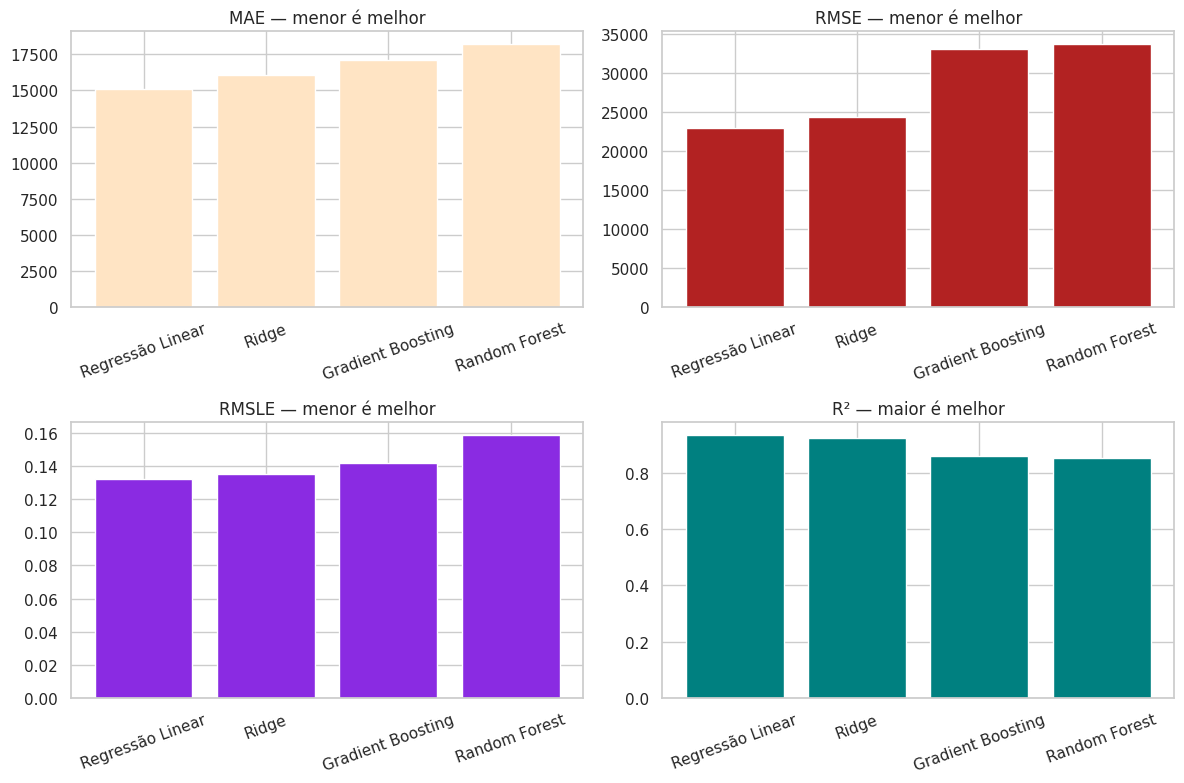

In [ ]:
plot_df = results_df.reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].bar(plot_df['Modelo'], plot_df['MAE'], color='bisque')
axes[0,0].set_title('MAE — menor é melhor')

axes[0,1].bar(plot_df['Modelo'], plot_df['RMSE'], color='firebrick')
axes[0,1].set_title('RMSE — menor é melhor')

axes[1,0].bar(plot_df['Modelo'], plot_df['RMSLE'], color='blueviolet')
axes[1,0].set_title('RMSLE — menor é melhor')

axes[1,1].bar(plot_df['Modelo'], plot_df['R2'], color='teal')
axes[1,1].set_title('R² — maior é melhor')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 16. Validação cruzada

In [38]:
best_name=results_df.index[0]
best_pipeline=fitted[best_name]
cv_scores=-cross_val_score(best_pipeline, X, y, cv=3, scoring='neg_root_mean_squared_error', n_jobs=1)
print('Melhor modelo:',best_name)
print('Scores:',np.round(cv_scores,4))
print('Média:',round(cv_scores.mean(),4),'Desvio:',round(cv_scores.std(),4))

Melhor modelo: Regressão Linear
Scores: [0.1374 0.1516 0.1587]
Média: 0.1492 Desvio: 0.0088


A validação cruzada treina e testa em diferentes divisões. Ela fornece uma avaliação mais estável. O sinal é invertido porque o Scikit-Learn usa scores negativos para erros.

## 17. Real versus previsto e resíduos

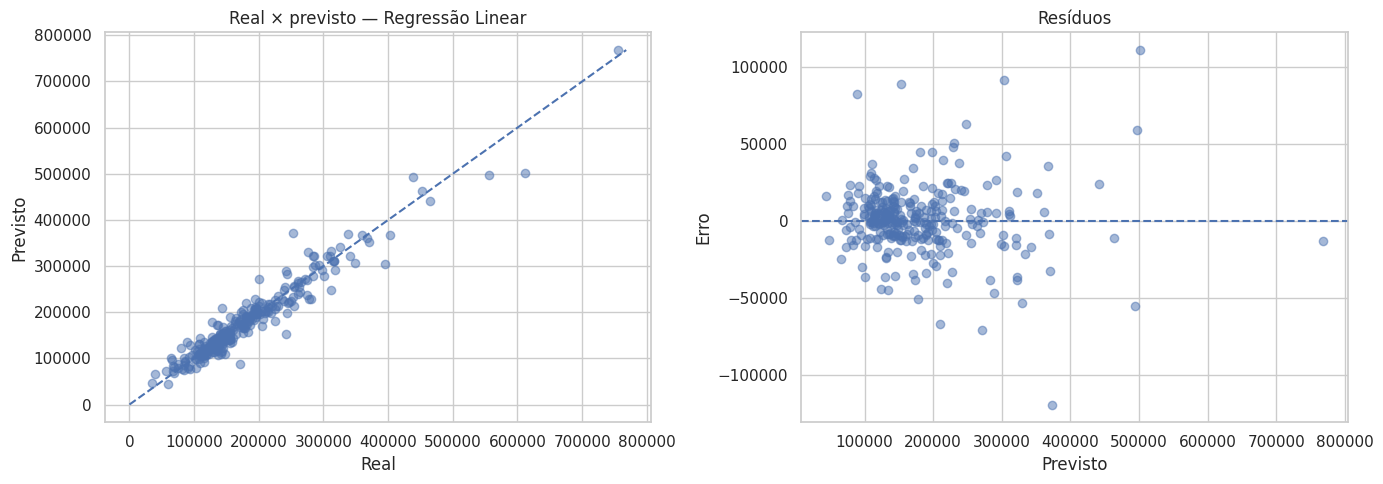

In [39]:
pred_log=best_pipeline.predict(X_valid)
pred=np.clip(np.expm1(pred_log),0,None)
real=np.expm1(y_valid)
residuals=real-pred
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(real,pred,alpha=.5)
lim=max(real.max(),pred.max()); axes[0].plot([0,lim],[0,lim],'--')
axes[0].set_title(f'Real × previsto — {best_name}'); axes[0].set_xlabel('Real'); axes[0].set_ylabel('Previsto')
axes[1].scatter(pred,residuals,alpha=.5); axes[1].axhline(0,linestyle='--')
axes[1].set_title('Resíduos'); axes[1].set_xlabel('Previsto'); axes[1].set_ylabel('Erro')
plt.tight_layout(); plt.show()

Pontos próximos da diagonal indicam boas previsões. Resíduos devem ficar distribuídos ao redor de zero sem padrão evidente.

## 18. Ajuste de hiperparâmetros

Hiperparâmetros são configurações definidas antes do treinamento. Diferentemente dos coeficientes aprendidos pelo modelo, eles controlam como o algoritmo aprende.

Nesta etapa, o `RandomizedSearchCV` testa combinações de hiperparâmetros do Gradient Boosting. Cada combinação é avaliada por validação cruzada, e a melhor configuração é escolhida pelo menor RMSE na escala logarítmica.


In [49]:
# Pipeline que será otimizado
tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

# Espaço de busca dos hiperparâmetros
param_distributions = {
    'model__n_estimators': [100, 150, 200, 300],
    'model__learning_rate': [0.02, 0.03, 0.05, 0.08, 0.10],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__loss': ['squared_error', 'huber']
}

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print('Melhores hiperparâmetros:')
print(random_search.best_params_)
print('\nMelhor RMSE médio de validação cruzada:',
      round(-random_search.best_score_, 4))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Melhores hiperparâmetros:
{'model__subsample': 0.7, 'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__loss': 'huber', 'model__learning_rate': 0.08}

Melhor RMSE médio de validação cruzada: 0.124


In [48]:
# Avaliação do modelo otimizado no conjunto de validação
tuned_pipeline = random_search.best_estimator_

tuned_pred_log = tuned_pipeline.predict(X_valid)
tuned_real = np.expm1(y_valid)
tuned_pred = np.clip(np.expm1(tuned_pred_log), 0, None)

tuned_metrics = pd.DataFrame({
    'MAE': [mean_absolute_error(tuned_real, tuned_pred)],
    'RMSE': [mean_squared_error(tuned_real, tuned_pred) ** 0.5],
    'RMSLE': [mean_squared_log_error(tuned_real, tuned_pred) ** 0.5],
    'R2': [r2_score(tuned_real, tuned_pred)]
}, index=['Gradient Boosting otimizado'])

tuned_metrics.round(4)


,MAE,RMSE,RMSLE,R2
Gradient Boosting otimizado,15479.1298,28379.0369,0.1333,0.895


In [26]:
# Inclui o modelo otimizado na comparação geral
results_df.loc['Gradient Boosting otimizado'] = tuned_metrics.iloc[0]
results_df = results_df.sort_values('RMSLE')

fitted['Gradient Boosting otimizado'] = tuned_pipeline

best_name = results_df.index[0]
best_pipeline = fitted[best_name]

results_df.round(4)


,MAE,RMSE,RMSLE,R2
Modelo,,,,
Regressão Linear,15084.3568,22912.5808,0.1322,0.9316
Gradient Boosting otimizado,15479.1298,28379.0369,0.1333,0.8950
Ridge,16033.6695,24365.8516,0.1352,0.9226
Gradient Boosting,17073.0253,33043.1882,0.1418,0.8577
Random Forest,18178.3420,33598.4465,0.1583,0.8528


,MAE,RMSE,RMSLE,R2
Modelo,,,,
Regressão Linear,15084.3568,22912.5808,0.1322,0.9316
Gradient Boosting otimizado,15479.1298,28379.0369,0.1333,0.8950
Ridge,16033.6695,24365.8516,0.1352,0.9226
Gradient Boosting,17073.0253,33043.1882,0.1418,0.8577
Random Forest,18178.3420,33598.4465,0.1583,0.8528


## 19. Aprendizado não supervisionado — K-Means e clusterização

Na regressão, o modelo aprende usando uma resposta conhecida, o `SalePrice`. Já no aprendizado não supervisionado, não existe uma resposta correta fornecida ao algoritmo.

O K-Means agrupa imóveis semelhantes de acordo com suas características. Cada grupo recebe o nome de **cluster**. O algoritmo procura reduzir a distância entre os imóveis e o centro do seu respectivo cluster.

Como o K-Means utiliza distâncias, as variáveis precisam estar na mesma escala. Por isso, os valores ausentes são preenchidos e as colunas são padronizadas antes da clusterização.


In [27]:
# Variáveis numéricas escolhidas para representar tamanho, qualidade e idade
cluster_features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageCars',
    'YearBuilt',
    'TotalBathrooms',
    'TotalSF'
]

cluster_data = train_eng[cluster_features].copy()

cluster_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cluster_scaled = cluster_preprocessor.fit_transform(cluster_data)
print('Formato dos dados utilizados no K-Means:', cluster_scaled.shape)


Formato dos dados utilizados no K-Means: (1460, 7)
Formato dos dados utilizados no K-Means: (1460, 7)


In [28]:
# Escolha do número de clusters pelo coeficiente de silhueta
cluster_evaluation = []

for k in range(2, 9):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    labels_temp = kmeans_temp.fit_predict(cluster_scaled)

    cluster_evaluation.append({
        'k': k,
        'Inércia': kmeans_temp.inertia_,
        'Silhueta': silhouette_score(cluster_scaled, labels_temp)
    })

cluster_evaluation_df = pd.DataFrame(cluster_evaluation)
cluster_evaluation_df


,k,Inércia,Silhueta
0,2,6201.836276,0.339055
1,3,5098.755572,0.265571
2,4,4607.529143,0.243159
3,5,4233.134924,0.199631
4,6,3917.164564,0.188302
5,7,3632.391538,0.192698
6,8,3433.583399,0.195477


,k,Inércia,Silhueta
0,2,6201.836276,0.339055
1,3,5098.755572,0.265571
2,4,4607.529143,0.243159
3,5,4233.134924,0.199631
4,6,3917.164564,0.188302
5,7,3632.391538,0.192698
6,8,3433.583399,0.195477


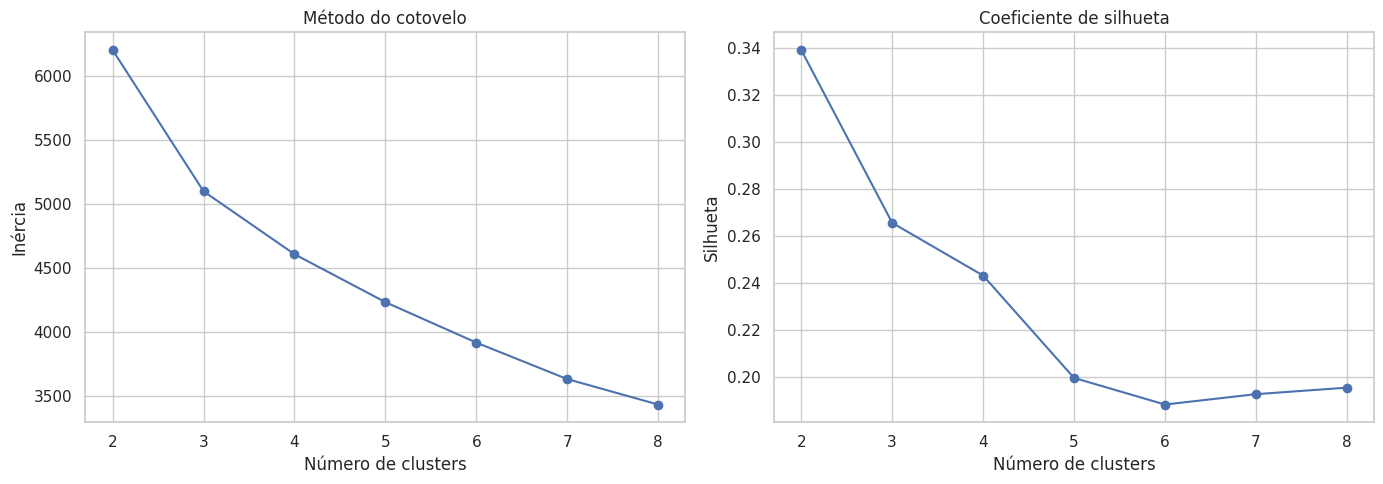

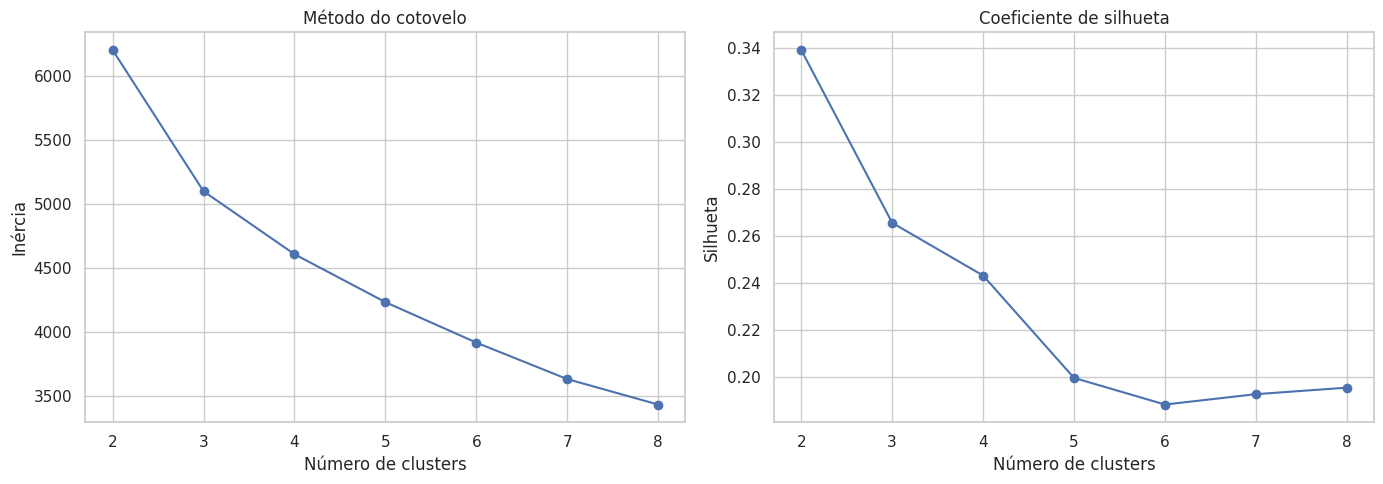

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    cluster_evaluation_df['k'],
    cluster_evaluation_df['Inércia'],
    marker='o'
)
axes[0].set_title('Método do cotovelo')
axes[0].set_xlabel('Número de clusters')
axes[0].set_ylabel('Inércia')

axes[1].plot(
    cluster_evaluation_df['k'],
    cluster_evaluation_df['Silhueta'],
    marker='o'
)
axes[1].set_title('Coeficiente de silhueta')
axes[1].set_xlabel('Número de clusters')
axes[1].set_ylabel('Silhueta')

plt.tight_layout()
plt.show()


In [41]:
# Seleciona automaticamente o k com maior coeficiente de silhueta
best_k = int(
    cluster_evaluation_df.loc[
        cluster_evaluation_df['Silhueta'].idxmax(), 'k'
    ]
)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

train_eng['Cluster'] = kmeans.fit_predict(cluster_scaled)

print('Número escolhido de clusters:', best_k)
print(train_eng['Cluster'].value_counts().sort_index())


Número escolhido de clusters: 2
Cluster
0    709
1    751
Name: count, dtype: int64


In [42]:
# Perfil médio dos grupos, usando SalePrice apenas para interpretação
cluster_profile = (
    train_eng.groupby('Cluster')[
        cluster_features + ['SalePrice']
    ]
    .mean()
    .round(2)
)

cluster_profile


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,TotalBathrooms,TotalSF,SalePrice
Cluster,,,,,,,,
0,7.07,1831.83,1290.24,2.23,1991.39,2.76,3118.63,234970.23
1,5.18,1216.79,837.64,1.33,1952.27,1.69,2046.31,129894.88


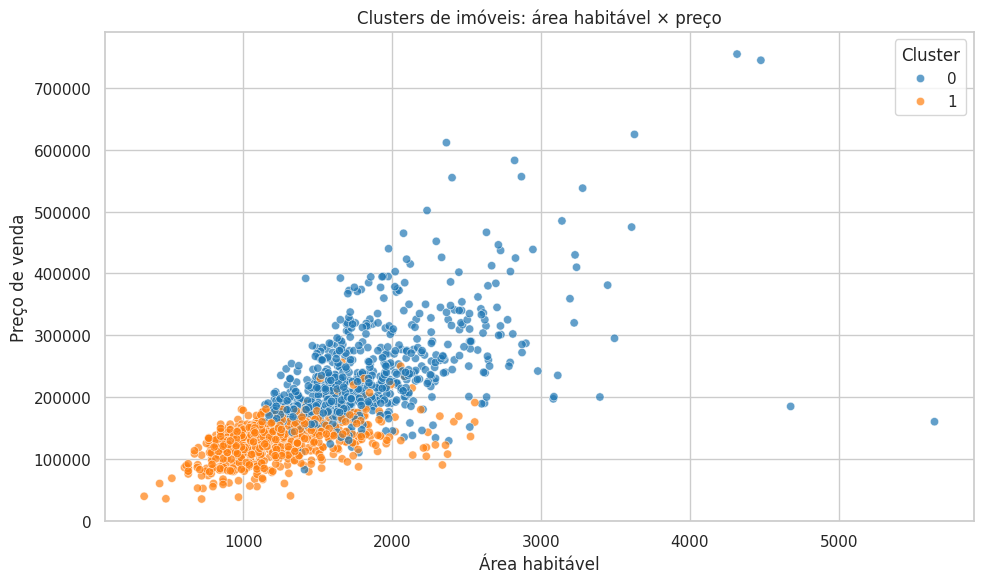

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_eng,
    x='GrLivArea',
    y='SalePrice',
    hue='Cluster',
    palette='tab10',
    alpha=0.7
)

plt.title('Clusters de imóveis: área habitável × preço')
plt.xlabel('Área habitável')
plt.ylabel('Preço de venda')
plt.tight_layout()
plt.show()


### Como interpretar os clusters

- Um cluster pode reunir imóveis maiores, novos e de qualidade superior.
- Outro pode representar imóveis menores e mais antigos.
- O preço médio pode ser usado para descrever os grupos depois que eles forem criados, mas não participa do treinamento do K-Means.
- A clusterização não substitui a regressão. Ela complementa a análise ao revelar perfis de imóveis presentes no conjunto de dados.


## 20. Importância das variáveis

In [44]:
importance_name = best_name if best_name in ['Random Forest','Gradient Boosting'] else 'Gradient Boosting'
imp_pipe=fitted[importance_name]
feature_names=imp_pipe.named_steps['preprocessor'].get_feature_names_out()
importances=imp_pipe.named_steps['model'].feature_importances_
imp_df=pd.DataFrame({'Variável':feature_names,'Importância':importances}).sort_values('Importância',ascending=False).head(20)
imp_df

,Variável,Importância
36,num__TotalSF,0.390786
3,num__OverallQual,0.341101
37,num__TotalBathrooms,0.046693
25,num__GarageCars,0.021414
2,num__LotArea,0.019310
5,num__YearBuilt,0.018926
40,num__RemodAge,0.018490
241,cat__KitchenQual_TA,0.013209
15,num__GrLivArea,0.013047
6,num__YearRemodAdd,0.011596


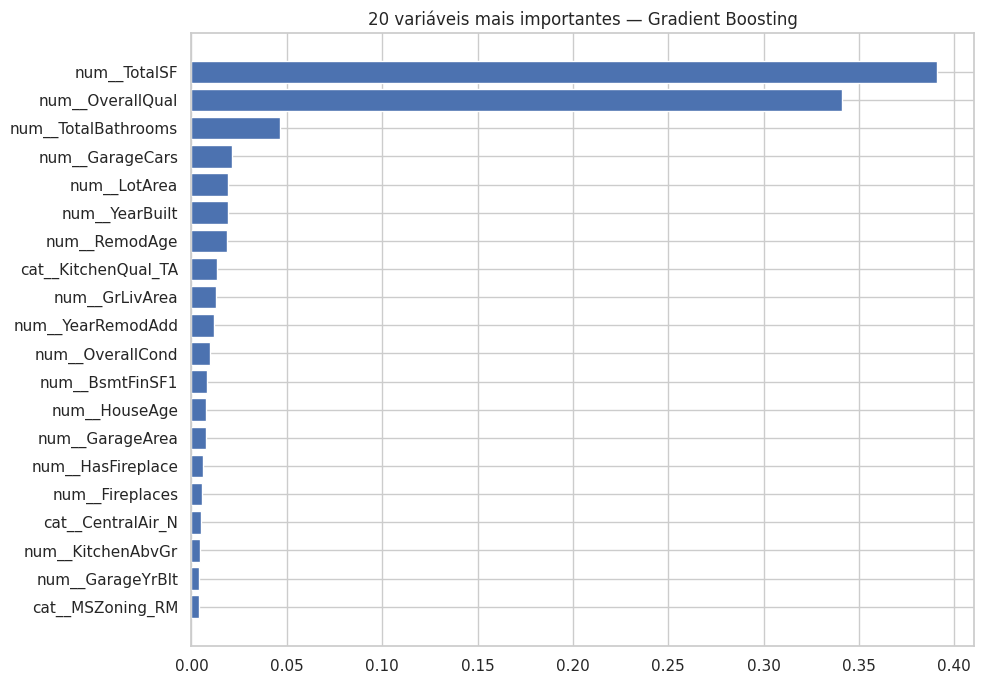

In [45]:
p=imp_df.sort_values('Importância')
plt.figure(figsize=(10,7)); plt.barh(p['Variável'],p['Importância'])
plt.title(f'20 variáveis mais importantes — {importance_name}')
plt.tight_layout(); plt.show()

`feature_importances_` mede a contribuição das variáveis para reduzir erros nas árvores. Importância não significa causalidade.

## 21. Treinamento final e submissão

In [46]:
# Clona a estrutura do melhor pipeline e treina novamente com todos os dados
from sklearn.base import clone

final_pipeline = clone(best_pipeline)
final_pipeline.fit(X, y)

test_pred = np.clip(
    np.expm1(final_pipeline.predict(X_test)),
    0,
    None
)

submission = sample_submission.copy()
submission['SalePrice'] = test_pred
submission.to_csv('/content/submission_house_prices.csv', index=False)

submission.head()


,Id,SalePrice
0,1461,121583.898420
1,1462,167046.676884
2,1463,182942.481768
3,1464,203639.273213
4,1465,193861.491119


O melhor modelo é treinado novamente com todo o conjunto de treino. `to_csv(index=False)` cria o arquivo de envio sem salvar o índice do Pandas.

## 22. Resultado final

In [47]:
best=results_df.iloc[0]
print('Melhor modelo:',best_name)
print(f"MAE: US$ {best['MAE']:,.2f} | Em média, o modelo erra aproximadamente US$ 15 mil por imóvel.")
print(f"RMSE: US$ {best['RMSE']:,.2f} | Quando o modelo erra muito, esses erros aumentam bastante a média.")
print(f"RMSLE: {best['RMSLE']:.4f} | O modelo apresenta um erro proporcional relativamente pequeno.")
print(f"R²: {best['R2']:.4f} | O modelo consegue explicar aproximadamente 93% da variação observada nos preços dos imóveis.")

Melhor modelo: Regressão Linear
MAE: US$ 15,084.36 | Em média, o modelo erra aproximadamente US$ 15 mil por imóvel.
RMSE: US$ 22,912.58 | Quando o modelo erra muito, esses erros aumentam bastante a média.
RMSLE: 0.1322 | O modelo apresenta um erro proporcional relativamente pequeno.
R²: 0.9316 | O modelo consegue explicar aproximadamente 93% da variação observada nos preços dos imóveis.


## 23. Conclusão
Foram comparados diferentes algoritmos de regressão, como Regressão Linear, Ridge, Random Forest e Gradient Boosting, utilizando métricas como MAE, RMSE, RMSLE e R² para avaliar o desempenho. Essa comparação mostrou que modelos baseados em árvores tendem a capturar melhor relações não lineares presentes nos dados, alcançando desempenho superior aos modelos lineares.

Além da avaliação tradicional com conjunto de validação, foi utilizada validação cruzada, proporcionando uma estimativa mais confiável da capacidade de generalização do modelo e reduzindo a dependência de uma única divisão entre treino e teste.

Por fim, o melhor modelo foi treinado utilizando todo o conjunto de treinamento e empregado para gerar previsões sobre o conjunto de teste, produzindo o arquivo de submissão no formato esperado pela competição.

De maneira geral, o projeto demonstrou a importância de todas as etapas do processo de Ciência de Dados — desde a exploração dos dados e engenharia de atributos até a comparação de modelos e validação estatística. Os resultados mostram que a combinação de um bom pré-processamento com modelos de ensemble pode produzir previsões bastante precisas para problemas de regressão em dados tabulares.

## 24. Glossário de funções

| Função/classe | Finalidade |
|---|---|
| `read_csv` | ler CSV |
| `head` | primeiras linhas |
| `info` | estrutura e tipos |
| `describe` | estatísticas |
| `isna` | identificar nulos |
| `drop` | remover colunas |
| `fillna` | preencher nulos |
| `select_dtypes` | selecionar por tipo |
| `log1p` / `expm1` | transformar e reverter o alvo |
| `train_test_split` | treino/validação |
| `SimpleImputer` | imputação |
| `StandardScaler` | padronização |
| `OneHotEncoder` | categorias para 0/1 |
| `ColumnTransformer` | tratamentos por grupo |
| `Pipeline` | encadear etapas |
| `fit` | treinar |
| `predict` | prever |
| `cross_val_score` | validação cruzada |
| `to_csv` | salvar resultado |